# Vector Index Performance Investigation

Comparing brute force, clustering (IVF), graph (HNSW), and LSH indexes
on search quality (precision / recall) and speed.

Indexes are implemented with [FAISS](https://github.com/facebookresearch/faiss/wiki) and [FALCONN](https://github.com/FALCONN-LIB/FALCONN).

## Google Colab Setup

Run the cells in this section **only if you are on Google Colab**.
They handle Python version verification, dependency installation, and dataset downloads.
Skip this section if running locally.

In [1]:
import sys, subprocess, os

# ── Install dependencies ─────────────────────────────────────────────────────
packages = ["faiss-cpu", "numpy", "h5py"]
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"  {pkg:<12} {status}")
    if result.returncode != 0:
        print(f"    {result.stderr.strip()}")

# ── Download datasets ────────────────────────────────────────────────────────
os.makedirs("datasets", exist_ok=True)

datasets = [
    ("word2vec_sample_150000.npy",
        "https://github.com/blues/vector-index-performance-investigation/raw/main/word2vec_sample_150000.npy"),
    ("datasets/glove-25-angular.hdf5",           "http://ann-benchmarks.com/glove-25-angular.hdf5"),
    ("datasets/glove-50-angular.hdf5",           "http://ann-benchmarks.com/glove-50-angular.hdf5"),
    ("datasets/glove-100-angular.hdf5",          "http://ann-benchmarks.com/glove-100-angular.hdf5"),
    ("datasets/fashion-mnist-784-euclidean.hdf5","http://ann-benchmarks.com/fashion-mnist-784-euclidean.hdf5"),
    ("datasets/sift-128-euclidean.hdf5",         "http://ann-benchmarks.com/sift-128-euclidean.hdf5"),
    ("datasets/deep-image-96-angular.hdf5",      "http://ann-benchmarks.com/deep-image-96-angular.hdf5"),
]

for dest, url in datasets:
    if os.path.exists(dest):
        print(f"  {dest} — already exists, skipping")
    else:
        print(f"  Downloading {dest}...")
        result = subprocess.run(["curl", "-L", "-o", dest, url], capture_output=True)
        if result.returncode == 0:
            print(f"    OK ({os.path.getsize(dest) // 1_000_000} MB)")
        else:
            print(f"    FAILED")

  faiss-cpu    OK
  numpy        OK
  h5py         OK
  word2vec_sample_150000.npy — already exists, skipping
  datasets/glove-25-angular.hdf5 — already exists, skipping
  datasets/glove-50-angular.hdf5 — already exists, skipping
  datasets/glove-100-angular.hdf5 — already exists, skipping
  datasets/fashion-mnist-784-euclidean.hdf5 — already exists, skipping
  datasets/sift-128-euclidean.hdf5 — already exists, skipping
  datasets/deep-image-96-angular.hdf5 — already exists, skipping


In [2]:
# Python 3
#!pip install faiss-cpu 
#!pip install falconn # Compitable with Python 3.10 and before, not working with Python 3.11 -- will have compilation errors when installing to Python 3.11.
#!pip install numpy

## Setup

Additional datasets from https://github.com/erikbern/ann-benchmarks

---

## Datasets

Download datasets before running this cell:
```
curl -O http://ann-benchmarks.com/glove-25-angular.hdf5
curl -O http://ann-benchmarks.com/glove-50-angular.hdf5
curl -O http://ann-benchmarks.com/glove-100-angular.hdf5
curl -O http://ann-benchmarks.com/fashion-mnist-784-euclidean.hdf5
curl -O http://ann-benchmarks.com/sift-128-euclidean.hdf5
```
See `datasets/datasets.txt` for descriptions of each dataset and their role in the evaluation.

In [5]:
#!pip install h5py
import h5py

def load_hdf5_dataset(path, n_train=None, n_queries=1000, normalize=False):
    """
    Load a dataset in ann-benchmarks HDF5 format.

    Parameters
    ----------
    path       : path to the .hdf5 file
    n_train    : number of corpus vectors to load (None = all)
    n_queries  : number of query vectors to load (default 1000)
    normalize  : L2-normalize vectors (set True for angular/cosine datasets)

    Returns
    -------
    data       : float32 array (n_train, dim)
    queries    : float32 array (n_queries, dim)
    gt_indices : int array (n_queries, 100) — pre-computed ground truth
    """
    with h5py.File(path, "r") as f:
        data    = np.array(f["train"][:n_train],      dtype=np.float32)
        queries = np.array(f["test"][:n_queries],     dtype=np.float32)
        gt      = np.array(f["neighbors"][:n_queries], dtype=np.int64)
    if normalize:
        data    = data    / (np.linalg.norm(data,    axis=1, keepdims=True) + 1e-10)
        queries = queries / (np.linalg.norm(queries, axis=1, keepdims=True) + 1e-10)
    print(f"Loaded {path}")
    print(f"  corpus : {data.shape}, queries: {queries.shape}")
    return data, queries, gt


# ── Load all datasets ────────────────────────────────────────────────────────
# angular/cosine datasets: normalize=True so inner product == cosine similarity
# euclidean datasets: normalize=False, use METRIC_L2 indexes

glove25_data,  glove25_queries,  glove25_gt  = load_hdf5_dataset(
    "datasets/glove-25-angular.hdf5", normalize=True)

glove50_data,  glove50_queries,  glove50_gt  = load_hdf5_dataset(
    "datasets/glove-50-angular.hdf5", normalize=True)

glove100_data, glove100_queries, glove100_gt = load_hdf5_dataset(
    "datasets/glove-100-angular.hdf5", normalize=True)

fmnist_data,   fmnist_queries,   fmnist_gt   = load_hdf5_dataset(
    "datasets/fashion-mnist-784-euclidean.hdf5")

# SIFT: load 150K for initial experiments; larger sizes loaded on demand in scale sweep
sift_150k_data, sift_queries, sift_gt = load_hdf5_dataset(
    "datasets/sift-128-euclidean.hdf5", n_train=150_000)

Loaded datasets/glove-25-angular.hdf5
  corpus : (1183514, 25), queries: (1000, 25)
Loaded datasets/glove-50-angular.hdf5
  corpus : (1183514, 50), queries: (1000, 50)
Loaded datasets/glove-100-angular.hdf5
  corpus : (1183514, 100), queries: (1000, 100)
Loaded datasets/fashion-mnist-784-euclidean.hdf5
  corpus : (60000, 784), queries: (1000, 784)
Loaded datasets/sift-128-euclidean.hdf5
  corpus : (150000, 128), queries: (1000, 128)


In [4]:
import faiss
import numpy as np
import time

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

os.makedirs("figures", exist_ok=True)

In [6]:
data_path = "./word2vec_sample_150000.npy"

data = np.load(data_path)
data_size, data_dim = data.shape
data_size, data_dim

(150000, 300)

In [7]:
queries = data[:1000] 
k = 100

In [8]:
def ann_search(index_name, index, queries, k, record_time=True):
    """Run search for all queries and return scores and indices.
    All indexes (FAISS flat, IVF, HNSW, LSH) share the same interface.
    """
    all_sim_scores, all_top_k_indices = [], []
    s = time.time()
    for i in range(len(queries)):
        query = np.array([queries[i]])
        sim_scores, top_k_indices = index.search(query, k)
        all_sim_scores.append(sim_scores[0])
        all_top_k_indices.append(top_k_indices[0])
    if record_time:
        print("{} search time: {}s".format(index_name, time.time() - s))
    return all_sim_scores, all_top_k_indices

---

## Baseline Index Building

### Cosine distance (inner product on normalized vectors)

In [9]:
# brute force
index_flat = faiss.IndexFlatIP(data_dim)
s = time.time()
index_flat.add(data)
print("index_flat building time: {}s".format(time.time() - s))


index_flat building time: 0.11638593673706055s


In [10]:
# clustering-based 
num_clusters = 10
quantizer = faiss.IndexFlatIP(data_dim)
index_clustering = faiss.IndexIVFFlat(quantizer, data_dim, num_clusters, faiss.METRIC_INNER_PRODUCT)
s = time.time()
index_clustering.train(data)    
index_clustering.add(data)
print("index_clustering building time: {}s".format(time.time() - s))


index_clustering building time: 0.2041010856628418s


In [11]:
# graph-based
hnsw_m = 8  
# efsearch in HNSW is a key parameter for quality-speed trade-off.
# Its default value is 16.
# Larger efsearch leads to higher accuracy and longer search time.
hnsw_efsearch = 32
index_graph = faiss.IndexHNSWFlat(data_dim, hnsw_m, faiss.METRIC_INNER_PRODUCT)
index_graph.hnsw.efSearch = hnsw_efsearch
s = time.time()
index_graph.train(data)    
index_graph.add(data)
print("index_graph building time: {}s".format(time.time() - s))


index_graph building time: 2.2455129623413086s


In [12]:
# LSH — faiss.IndexLSH uses random hyperplane hashing.
# nbits controls the length of each binary hash code;
# more bits = finer approximation, larger memory footprint.
nbits = 256
index_lsh = faiss.IndexLSH(data_dim, nbits)
s = time.time()
index_lsh.add(data)
print("index_lsh building time: {}s".format(time.time() - s))

index_lsh building time: 0.09505200386047363s


In [13]:
# Run search on each index and print timing
ann_search("index_flat",       index_flat,       queries, k)
ann_search("index_clustering", index_clustering, queries, k)
ann_search("index_graph",      index_graph,      queries, k)
ann_search("index_lsh",        index_lsh,        queries, k)

index_flat search time: 6.377867937088013s
index_clustering search time: 0.8325550556182861s
index_graph search time: 0.0699608325958252s
index_lsh search time: 0.60052490234375s


([array([  0.,  93.,  96.,  97.,  97.,  98.,  98.,  98.,  99., 100., 100.,
         100., 100., 100., 100., 100., 100., 101., 101., 101., 101., 101.,
         101., 101., 102., 102., 102., 102., 102., 102., 102., 102., 102.,
         102., 102., 102., 102., 102., 102., 102., 102., 102., 102., 102.,
         102., 103., 103., 103., 103., 103., 103., 103., 103., 103., 103.,
         103., 103., 103., 103., 103., 103., 103., 103., 103., 103., 103.,
         103., 103., 103., 103., 103., 104., 104., 104., 104., 104., 104.,
         104., 104., 104., 104., 104., 104., 104., 104., 104., 104., 104.,
         104., 104., 104., 104., 104., 104., 104., 104., 104., 104., 104.,
         104.], dtype=float32),
  array([ 0., 63., 75., 76., 79., 79., 81., 82., 82., 82., 83., 83., 85.,
         85., 85., 85., 86., 86., 87., 88., 88., 88., 89., 89., 89., 89.,
         89., 89., 89., 89., 89., 89., 90., 90., 90., 90., 90., 90., 91.,
         91., 91., 91., 91., 91., 91., 91., 91., 91., 91., 92., 92., 92

---

### Search Quality

In [14]:
def compute_quality(gt_indices, approx_indices):
    """
    Compute precision and recall for top-k approximate nearest neighbor results.
    
    Uses brute-force results as ground truth. For each query:
      TP = items in both approx results and ground truth
      FP = items in approx results but not in ground truth
      FN = items in ground truth but not in approx results
      precision = TP / (TP + FP)
      recall    = TP / (TP + FN)
    
    Returns the mean precision and recall across all queries.
    """
    precisions, recalls = [], []
    for gt, approx in zip(gt_indices, approx_indices):
        gt_set = set(gt)
        approx_set = set(approx)
        tp = len(gt_set & approx_set)
        fp = len(approx_set - gt_set)
        fn = len(gt_set - approx_set)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
    return np.mean(precisions), np.mean(recalls)

In [15]:
# Ground truth: brute-force (exact) top-k results
_, gt_indices = ann_search('index_flat', index_flat, queries, k, record_time=False)

# Approximate index results
_, clustering_indices = ann_search('index_clustering', index_clustering, queries, k)
_, graph_indices      = ann_search('index_graph',      index_graph,      queries, k)
_, lsh_indices        = ann_search('index_lsh',        index_lsh,        queries, k)

# Compute and print precision / recall for each index
for name, approx in [('clustering', clustering_indices),
                     ('graph',      graph_indices),
                     ('lsh',        lsh_indices)]:
    precision, recall = compute_quality(gt_indices, approx)
    print(f"{name:12s}  precision={precision:.4f}  recall={recall:.4f}")

index_clustering search time: 0.808851957321167s
index_graph search time: 0.06841182708740234s
index_lsh search time: 0.5967333316802979s
clustering    precision=0.1818  recall=0.1818
graph         precision=0.2958  recall=0.2958
lsh           precision=0.1430  recall=0.1430


---

### Evaluation 1: Distance Metric Comparison (Euclidean vs. Cosine)

For each index type, rebuild with both distance metrics and compare build time, search time, precision, and recall.

- **Cosine** (inner product on L2-normalized vectors) — `METRIC_INNER_PRODUCT`
- **Euclidean** (L2 distance on raw vectors) — `METRIC_L2`

The brute-force result for each metric serves as its own ground truth.

In [16]:
def evaluate_metric(data, queries, metric, k=100, num_clusters=10, hnsw_m=8,
                    hnsw_efsearch=32, lsh_nbits=256):
    """
    Build brute-force, clustering, graph, and LSH indexes for a given distance
    metric, run search, and return build time, search time, precision, and recall.

    Parameters
    ----------
    data     : float32 array (n, dim) — L2-normalized for cosine
    queries  : float32 array (q, dim) — L2-normalized for cosine
    metric   : 'cosine' or 'euclidean'
    """
    assert metric in ('cosine', 'euclidean')
    faiss_metric = faiss.METRIC_INNER_PRODUCT if metric == 'cosine' else faiss.METRIC_L2
    dim = data.shape[1]
    results = {}

    # Brute force (ground truth)
    bf = faiss.IndexFlatIP(dim) if metric == 'cosine' else faiss.IndexFlatL2(dim)
    bf.add(data)
    _, gt = ann_search('bf', bf, queries, k, record_time=False)

    # Clustering (IVF)
    quantizer = faiss.IndexFlatIP(dim) if metric == 'cosine' else faiss.IndexFlatL2(dim)
    idx_ivf = faiss.IndexIVFFlat(quantizer, dim, num_clusters, faiss_metric)
    t0 = time.time()
    idx_ivf.train(data); idx_ivf.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search('ivf', idx_ivf, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt, approx)
    results['clustering'] = dict(build=build_time, search=search_time, precision=p, recall=r)

    # Graph (HNSW)
    idx_hnsw = faiss.IndexHNSWFlat(dim, hnsw_m, faiss_metric)
    idx_hnsw.hnsw.efSearch = hnsw_efsearch
    t0 = time.time()
    idx_hnsw.train(data); idx_hnsw.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search('hnsw', idx_hnsw, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt, approx)
    results['graph'] = dict(build=build_time, search=search_time, precision=p, recall=r)

    # LSH (faiss.IndexLSH — random hyperplane hashing, metric-agnostic)
    idx_lsh = faiss.IndexLSH(dim, lsh_nbits)
    t0 = time.time()
    idx_lsh.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search('lsh', idx_lsh, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt, approx)
    results['lsh'] = dict(build=build_time, search=search_time, precision=p, recall=r)

    return results


def normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-10)


def print_metric_comparison(cosine_results, euclidean_results):
    header = f"{'Index':<12} {'Metric':<12} {'Build(s)':>10} {'Search(s)':>10} {'Precision':>10} {'Recall':>10}"
    print(header)
    print('-' * len(header))
    for idx_name in ('clustering', 'graph', 'lsh'):
        for metric, res in (('cosine', cosine_results), ('euclidean', euclidean_results)):
            r = res[idx_name]
            print(f"{idx_name:<12} {metric:<12} {r['build']:>10.3f} {r['search']:>10.3f} {r['precision']:>10.4f} {r['recall']:>10.4f}")

In [17]:
# word2vec vectors: normalize for cosine, use raw for Euclidean
data_f32 = data.astype(np.float32)
queries_f32 = queries.astype(np.float32)
data_norm = normalize(data_f32)
queries_norm = normalize(queries_f32)

print("=== word2vec (150K, 300-dim) ===\n")
cosine_results    = evaluate_metric(data_norm, queries_norm, metric='cosine')
euclidean_results = evaluate_metric(data_f32,  queries_f32,  metric='euclidean')
print_metric_comparison(cosine_results, euclidean_results)

=== word2vec (150K, 300-dim) ===

Index        Metric         Build(s)  Search(s)  Precision     Recall
---------------------------------------------------------------------
clustering   cosine            0.177      0.796     0.5988     0.5988
clustering   euclidean         0.096      2.249     0.8733     0.8733
graph        cosine            2.847      0.083     0.7057     0.7057
graph        euclidean         1.520      0.048     0.6426     0.6426
lsh          cosine            0.047      0.624     0.5260     0.5260
lsh          euclidean         0.044      0.629     0.2230     0.2230


---

### Evaluation 2: Parameter Sensitivity

For each index, vary its key parameters and measure the quality/speed tradeoff.

- **Clustering (IVF)**: `num_clusters` (build-time) and `nprobe` (search-time)
- **Graph (HNSW)**: `hnsw_m` (build-time) and `efSearch` (search-time)

Build-time parameters require rebuilding the index. Search-time parameters (`nprobe`, `efSearch`) only require re-running search on the same index.

In [18]:
def sweep_search_param(index, param_setter, param_values, queries, gt_indices, k, label):
    """
    Vary a search-time parameter on an already-built index.
    param_setter: callable(index, value) that sets the parameter in place.
    """
    print(f"\n--- {label} ---")
    print(f"{'param':>10} {'search(s)':>10} {'precision':>10} {'recall':>10}")
    for val in param_values:
        param_setter(index, val)
        t0 = time.time()
        _, approx = ann_search(label, index, queries, k, record_time=False)
        search_time = time.time() - t0
        p, r = compute_quality(gt_indices, approx)
        print(f"{val:>10} {search_time:>10.3f} {p:>10.4f} {r:>10.4f}")


def sweep_build_param(build_fn, param_values, data, queries, gt_indices, k, label):
    """
    Vary a build-time parameter by rebuilding the index each time.
    build_fn: callable(param_value) -> built faiss index
    """
    print(f"\n--- {label} ---")
    print(f"{'param':>10} {'build(s)':>10} {'search(s)':>10} {'precision':>10} {'recall':>10}")
    for val in param_values:
        index = build_fn(val)
        t_build = time.time()
        index.train(data)
        index.add(data)
        build_time = time.time() - t_build
        t0 = time.time()
        _, approx = ann_search(label, index, queries, k, record_time=False)
        search_time = time.time() - t0
        p, r = compute_quality(gt_indices, approx)
        print(f"{val:>10} {build_time:>10.3f} {search_time:>10.3f} {p:>10.4f} {r:>10.4f}")

In [19]:
# Use normalized word2vec data and cosine ground truth
dim = data_norm.shape[1]

# Ground truth for parameter sweeps
bf = faiss.IndexFlatIP(dim)
bf.add(data_norm)
_, gt_norm = ann_search("bf", bf, queries_norm, k, record_time=False)

# ── Clustering: nprobe sweep (build once with num_clusters=50) ──────────────
quantizer = faiss.IndexFlatIP(dim)
ivf_fixed = faiss.IndexIVFFlat(quantizer, dim, 50, faiss.METRIC_INNER_PRODUCT)
ivf_fixed.train(data_norm)
ivf_fixed.add(data_norm)

sweep_search_param(
    ivf_fixed,
    param_setter=lambda idx, v: setattr(idx, "nprobe", v),
    param_values=[1, 2, 5, 10, 20, 50],
    queries=queries_norm, gt_indices=gt_norm, k=k,
    label="IVF nprobe (num_clusters=50)"
)

# ── Clustering: num_clusters sweep (nprobe fixed at 5) ───────────────────────
def build_ivf(num_clusters):
    q = faiss.IndexFlatIP(dim)
    idx = faiss.IndexIVFFlat(q, dim, num_clusters, faiss.METRIC_INNER_PRODUCT)
    idx.nprobe = min(5, num_clusters)
    return idx

sweep_build_param(
    build_ivf,
    param_values=[5, 10, 25, 50, 100, 200],
    data=data_norm, queries=queries_norm, gt_indices=gt_norm, k=k,
    label="IVF num_clusters (nprobe=5)"
)


--- IVF nprobe (num_clusters=50) ---
     param  search(s)  precision     recall
         1      0.149     0.4476     0.4476
         2      0.265     0.5918     0.5918
         5      0.617     0.7637     0.7637
        10      1.242     0.8685     0.8685
        20      2.491     0.9399     0.9399
        50      6.295     1.0000     1.0000

--- IVF num_clusters (nprobe=5) ---
     param   build(s)  search(s)  precision     recall
         5      0.141      6.320     1.0000     1.0000
        10      0.119      3.395     0.8952     0.8952
        25      0.085      1.346     0.8291     0.8291
        50      0.102      0.637     0.7637     0.7637
       100      0.142      0.349     0.7273     0.7273
       200      0.287      0.189     0.6854     0.6854


In [20]:
# ── Graph: efSearch sweep (build once with hnsw_m=8) ────────────────────────
hnsw_fixed = faiss.IndexHNSWFlat(dim, 8, faiss.METRIC_INNER_PRODUCT)
hnsw_fixed.train(data_norm)
hnsw_fixed.add(data_norm)

sweep_search_param(
    hnsw_fixed,
    param_setter=lambda idx, v: setattr(idx.hnsw, "efSearch", v),
    param_values=[8, 16, 32, 64, 128, 256],
    queries=queries_norm, gt_indices=gt_norm, k=k,
    label="HNSW efSearch (hnsw_m=8)"
)

# ── Graph: hnsw_m sweep (efSearch fixed at 32) ───────────────────────────────
def build_hnsw(m):
    idx = faiss.IndexHNSWFlat(dim, m, faiss.METRIC_INNER_PRODUCT)
    idx.hnsw.efSearch = 32
    return idx

sweep_build_param(
    build_hnsw,
    param_values=[4, 8, 16, 32, 64],
    data=data_norm, queries=queries_norm, gt_indices=gt_norm, k=k,
    label="HNSW hnsw_m (efSearch=32)"
)


--- HNSW efSearch (hnsw_m=8) ---
     param  search(s)  precision     recall
         8      0.040     0.4315     0.4062
        16      0.056     0.5579     0.5566
        32      0.085     0.7103     0.7103
        64      0.132     0.8365     0.8365
       128      0.220     0.9149     0.9149
       256      0.442     0.9539     0.9539

--- HNSW hnsw_m (efSearch=32) ---
     param   build(s)  search(s)  precision     recall
         4      2.521      0.079     0.5363     0.5359
         8      2.753      0.082     0.7108     0.7108
        16      2.960      0.092     0.7756     0.7756
        32      5.208      0.136     0.8915     0.8915
        64      5.985      0.172     0.9295     0.9295


--- LSH nbits ---
   nbits   build(s)  search(s)  precision     recall
      64      0.437      0.510     0.1477     0.1477
     128      0.026      0.487     0.3052     0.3052
     256      0.045      0.492     0.5260     0.5260
     512      0.085      0.583     0.6640     0.6640
    1024      0.170      0.979     0.7568     0.7568


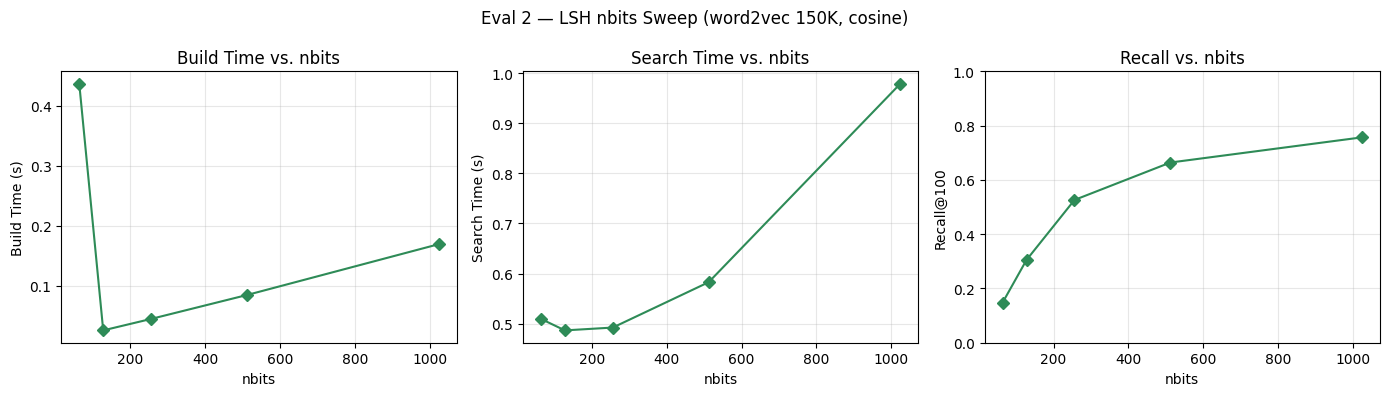

In [31]:
# ── LSH: nbits sweep (word2vec 150K, cosine — same setting as IVF/HNSW sweeps) ──
print("--- LSH nbits ---")
print(f"{'nbits':>8} {'build(s)':>10} {'search(s)':>10} {'precision':>10} {'recall':>10}")

nbits_vals = [64, 128, 256, 512, 1024]
lsh_bt, lsh_st, lsh_prec, lsh_rec = [], [], [], []

for nbits in nbits_vals:
    idx = faiss.IndexLSH(dim, nbits)
    t0 = time.time(); idx.add(data_norm)
    bt = time.time() - t0
    t0 = time.time()
    _, approx = ann_search("lsh", idx, queries_norm, k, record_time=False)
    st = time.time() - t0
    p, r = compute_quality(gt_norm, approx)
    lsh_bt.append(bt); lsh_st.append(st); lsh_prec.append(p); lsh_rec.append(r)
    print(f"{nbits:>8} {bt:>10.3f} {st:>10.3f} {p:>10.4f} {r:>10.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Eval 2 — LSH nbits Sweep (word2vec 150K, cosine)", fontsize=12)

axes[0].plot(nbits_vals, lsh_bt, "D-", color="seagreen")
axes[0].set_xlabel("nbits"); axes[0].set_ylabel("Build Time (s)")
axes[0].set_title("Build Time vs. nbits"); axes[0].grid(True, alpha=0.3)

axes[1].plot(nbits_vals, lsh_st, "D-", color="seagreen")
axes[1].set_xlabel("nbits"); axes[1].set_ylabel("Search Time (s)")
axes[1].set_title("Search Time vs. nbits"); axes[1].grid(True, alpha=0.3)

axes[2].plot(nbits_vals, lsh_rec, "D-", color="seagreen")
axes[2].set_xlabel("nbits"); axes[2].set_ylabel("Recall@100")
axes[2].set_title("Recall vs. nbits"); axes[2].set_ylim(0, 1.0); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/eval2_lsh_nbits.png", dpi=150, bbox_inches="tight")
plt.show()

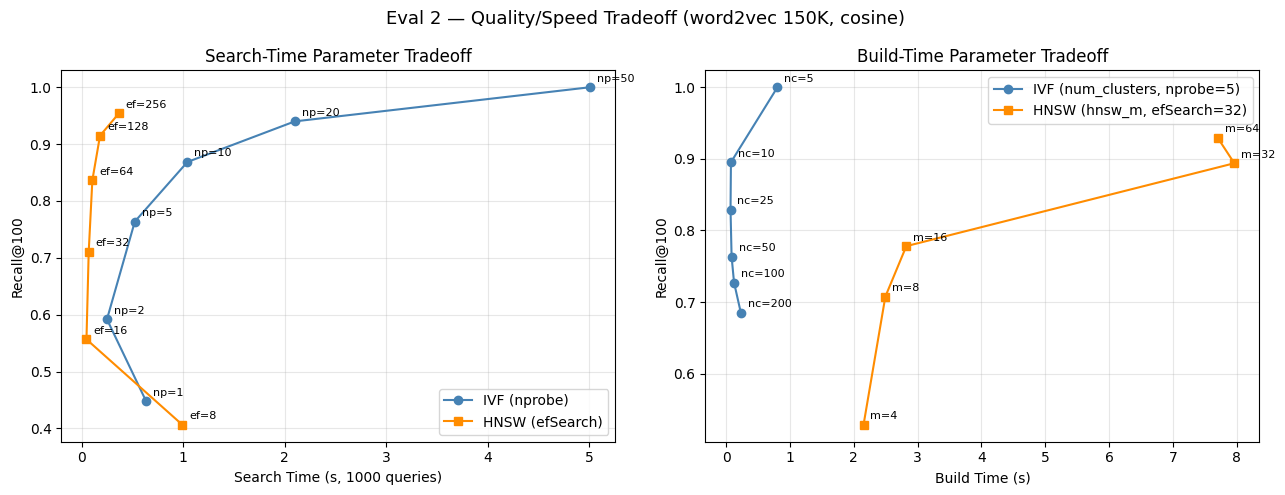

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Eval 2 — Quality/Speed Tradeoff (word2vec 150K, cosine)", fontsize=13)

# ── Search-time parameter sweep ──────────────────────────────────────────────
nprobe_vals   = [1, 2, 5, 10, 20, 50]
efsearch_vals = [8, 16, 32, 64, 128, 256]

ivf_st, ivf_rc = [], []
for v in nprobe_vals:
    ivf_fixed.nprobe = v
    t0 = time.time()
    _, approx = ann_search("", ivf_fixed, queries_norm, k, record_time=False)
    ivf_st.append(time.time() - t0)
    _, r = compute_quality(gt_norm, approx)
    ivf_rc.append(r)

hnsw_st, hnsw_rc = [], []
for v in efsearch_vals:
    hnsw_fixed.hnsw.efSearch = v
    t0 = time.time()
    _, approx = ann_search("", hnsw_fixed, queries_norm, k, record_time=False)
    hnsw_st.append(time.time() - t0)
    _, r = compute_quality(gt_norm, approx)
    hnsw_rc.append(r)

ax = axes[0]
ax.plot(ivf_st, ivf_rc, "o-", label="IVF (nprobe)", color="steelblue")
for x, y, v in zip(ivf_st, ivf_rc, nprobe_vals):
    ax.annotate(f"np={v}", (x, y), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.plot(hnsw_st, hnsw_rc, "s-", label="HNSW (efSearch)", color="darkorange")
for x, y, v in zip(hnsw_st, hnsw_rc, efsearch_vals):
    ax.annotate(f"ef={v}", (x, y), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Search Time (s, 1000 queries)")
ax.set_ylabel("Recall@100")
ax.set_title("Search-Time Parameter Tradeoff")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Build-time parameter sweep ────────────────────────────────────────────────
nc_vals = [5, 10, 25, 50, 100, 200]
nc_bt, nc_rc = [], []
for nc in nc_vals:
    q_ = faiss.IndexFlatIP(dim)
    idx_ = faiss.IndexIVFFlat(q_, dim, nc, faiss.METRIC_INNER_PRODUCT)
    idx_.nprobe = min(5, nc)
    t0 = time.time(); idx_.train(data_norm); idx_.add(data_norm)
    nc_bt.append(time.time() - t0)
    _, approx = ann_search("", idx_, queries_norm, k, record_time=False)
    _, r = compute_quality(gt_norm, approx)
    nc_rc.append(r)

m_vals = [4, 8, 16, 32, 64]
m_bt, m_rc = [], []
for m in m_vals:
    idx_ = faiss.IndexHNSWFlat(dim, m, faiss.METRIC_INNER_PRODUCT)
    idx_.hnsw.efSearch = 32
    t0 = time.time(); idx_.train(data_norm); idx_.add(data_norm)
    m_bt.append(time.time() - t0)
    _, approx = ann_search("", idx_, queries_norm, k, record_time=False)
    _, r = compute_quality(gt_norm, approx)
    m_rc.append(r)

ax = axes[1]
ax.plot(nc_bt, nc_rc, "o-", label="IVF (num_clusters, nprobe=5)", color="steelblue")
for x, y, v in zip(nc_bt, nc_rc, nc_vals):
    ax.annotate(f"nc={v}", (x, y), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.plot(m_bt, m_rc, "s-", label="HNSW (hnsw_m, efSearch=32)", color="darkorange")
for x, y, v in zip(m_bt, m_rc, m_vals):
    ax.annotate(f"m={v}", (x, y), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Build Time (s)")
ax.set_ylabel("Recall@100")
ax.set_title("Build-Time Parameter Tradeoff")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/eval2_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

---

### Evaluation 3: Multi-Dataset Evaluation

Three controlled experiments, each isolating one variable:

1. **Dimensionality** — word2vec (300-dim), GloVe-25 (25-dim), Fashion-MNIST (784-dim), all at ~60K vectors
2. **Scale** — SIFT at 150K, 500K, and 1M vectors (128-dim, Euclidean throughout)
3. **Distribution** — word2vec vs. SIFT at 150K vectors (text embeddings vs. image descriptors)

Brute force is recomputed as ground truth for each dataset/size combination.
Fixed parameters: `num_clusters=50`, `nprobe=10`, `hnsw_m=16`, `efSearch=64`.

In [21]:
def compute_gt(data, queries, metric, k):
    """Compute exact ground truth using brute force."""
    dim = data.shape[1]
    idx = faiss.IndexFlatIP(dim) if metric == "cosine" else faiss.IndexFlatL2(dim)
    idx.add(data)
    _, gt = ann_search("bf", idx, queries, k, record_time=False)
    return gt


def evaluate_dataset(data, queries, gt_indices, metric, k=100,
                     num_clusters=50, nprobe=10, hnsw_m=16, hnsw_efsearch=64,
                     lsh_nbits=256):
    """Build IVF, HNSW, and LSH indexes; run search; return quality and timing."""
    faiss_metric = faiss.METRIC_INNER_PRODUCT if metric == "cosine" else faiss.METRIC_L2
    dim = data.shape[1]
    results = {}

    # Clustering (IVF)
    quantizer = faiss.IndexFlatIP(dim) if metric == "cosine" else faiss.IndexFlatL2(dim)
    idx_ivf = faiss.IndexIVFFlat(quantizer, dim, num_clusters, faiss_metric)
    idx_ivf.nprobe = nprobe
    t0 = time.time()
    idx_ivf.train(data); idx_ivf.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search("ivf", idx_ivf, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt_indices, approx)
    results["clustering"] = dict(build=build_time, search=search_time, precision=p, recall=r)

    # Graph (HNSW)
    idx_hnsw = faiss.IndexHNSWFlat(dim, hnsw_m, faiss_metric)
    idx_hnsw.hnsw.efSearch = hnsw_efsearch
    t0 = time.time()
    idx_hnsw.train(data); idx_hnsw.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search("hnsw", idx_hnsw, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt_indices, approx)
    results["graph"] = dict(build=build_time, search=search_time, precision=p, recall=r)

    # LSH (faiss.IndexLSH — random hyperplane hashing)
    idx_lsh = faiss.IndexLSH(dim, lsh_nbits)
    t0 = time.time()
    idx_lsh.add(data)
    build_time = time.time() - t0
    t0 = time.time()
    _, approx = ann_search("lsh", idx_lsh, queries, k, record_time=False)
    search_time = time.time() - t0
    p, r = compute_quality(gt_indices, approx)
    results["lsh"] = dict(build=build_time, search=search_time, precision=p, recall=r)

    return results


def print_results(all_results, title):
    print(f"\n=== {title} ===")
    header = f"{'Dataset':<26} {'Index':<12} {'Build(s)':>9} {'Search(s)':>10} {'Precision':>10} {'Recall':>8}"
    print(header)
    print('-' * len(header))
    for label, res in all_results.items():
        for idx_name, r in res.items():
            print(f"{label:<26} {idx_name:<12} {r['build']:>9.3f} {r['search']:>10.3f} {r['precision']:>10.4f} {r['recall']:>8.4f}")
        print()

In [22]:
# ── Experiment 1: Dimensionality ─────────────────────────────────────────────
# Part A — Mixed comparison: different domains and metrics, scale fixed at 60K.
# Isolates broad dimension effects across data types.
N_DIM = 60_000
Q = 1000

wv_data  = normalize(data[:N_DIM].astype(np.float32))
wv_q     = normalize(data[:Q].astype(np.float32))
wv_gt    = compute_gt(wv_data, wv_q, "cosine", k)

g25_data = glove25_data[:N_DIM]
g25_q    = glove25_queries[:Q]
g25_gt   = compute_gt(g25_data, g25_q, "cosine", k)

fm_data  = fmnist_data
fm_q     = fmnist_queries[:Q]
fm_gt    = compute_gt(fm_data, fm_q, "euclidean", k)

dim_results = {
    "word2vec  (300-dim, cos)": evaluate_dataset(wv_data,  wv_q,  wv_gt,  "cosine",    k),
    "glove-25  ( 25-dim, cos)": evaluate_dataset(g25_data, g25_q, g25_gt, "cosine",    k),
    "fmnist    (784-dim, euc)": evaluate_dataset(fm_data,  fm_q,  fm_gt,  "euclidean", k),
}
print_results(dim_results, "Dimensionality Comparison — Mixed (60K vectors)")

# Part B — GloVe-only controlled sweep: same source, same metric, only dim varies.
# The cleanest isolation of the dimensionality effect.
glove_datasets = {
    "glove-25  ( 25-dim)": (glove25_data[:N_DIM],  glove25_queries[:Q],  "cosine"),
    "glove-50  ( 50-dim)": (glove50_data[:N_DIM],  glove50_queries[:Q],  "cosine"),
    "glove-100 (100-dim)": (glove100_data[:N_DIM], glove100_queries[:Q], "cosine"),
}

glove_results = {}
for label, (d, q, metric) in glove_datasets.items():
    gt = compute_gt(d, q, metric, k)
    glove_results[label] = evaluate_dataset(d, q, gt, metric, k)

print_results(glove_results, "Dimensionality Comparison — GloVe Controlled Sweep (60K vectors, cosine)")


=== Dimensionality Comparison — Mixed (60K vectors) ===
Dataset                    Index         Build(s)  Search(s)  Precision   Recall
--------------------------------------------------------------------------------
word2vec  (300-dim, cos)   clustering       0.077      0.594     0.8858   0.8858
word2vec  (300-dim, cos)   graph            0.981      0.133     0.9090   0.9090
word2vec  (300-dim, cos)   lsh              0.026      0.302     0.5534   0.5534

glove-25  ( 25-dim, cos)   clustering       0.024      0.118     0.9482   0.9482
glove-25  ( 25-dim, cos)   graph            0.343      0.073     0.8689   0.8689
glove-25  ( 25-dim, cos)   lsh              0.013      0.310     0.5823   0.5823

fmnist    (784-dim, euc)   clustering       0.130      1.109     0.9991   0.9991
fmnist    (784-dim, euc)   graph            1.237      0.165     0.9587   0.9587
fmnist    (784-dim, euc)   lsh              0.033      0.319     0.3283   0.3283


=== Dimensionality Comparison — GloVe Controlled

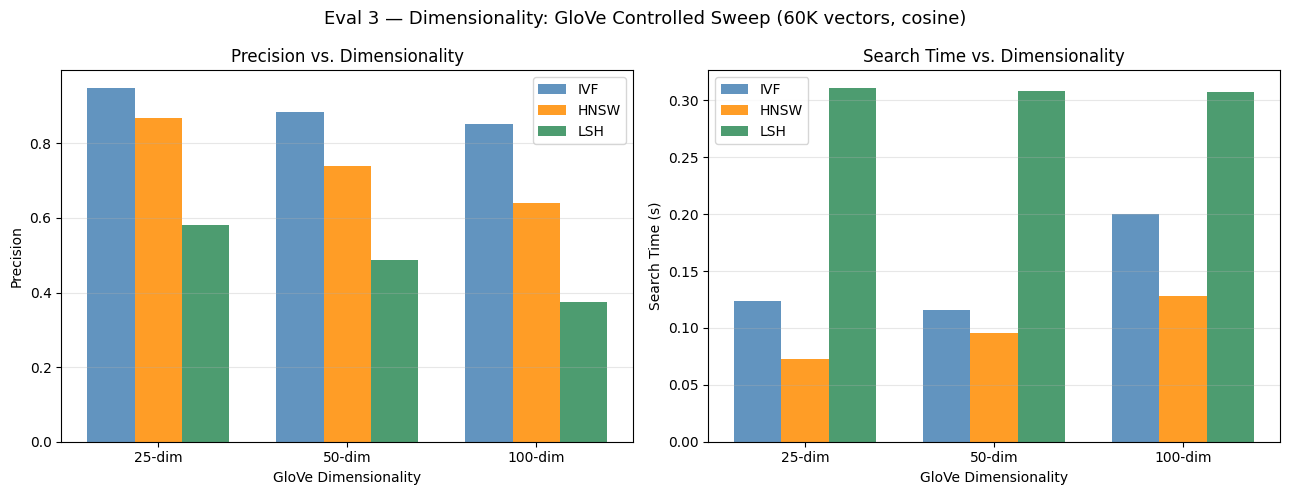

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Eval 3 — Dimensionality: GloVe Controlled Sweep (60K vectors, cosine)", fontsize=13)

glove_keys   = list(glove_results.keys())
dim_labels   = ["25-dim", "50-dim", "100-dim"]
indexes      = ["clustering", "graph", "lsh"]
display      = {"clustering": "IVF", "graph": "HNSW", "lsh": "LSH"}
colors       = {"clustering": "steelblue", "graph": "darkorange", "lsh": "seagreen"}
x = np.arange(len(dim_labels))
w = 0.25

for i, idx_name in enumerate(indexes):
    precs   = [glove_results[l][idx_name]["precision"] for l in glove_keys]
    searches = [glove_results[l][idx_name]["search"]   for l in glove_keys]
    axes[0].bar(x + i * w, precs,    w, label=display[idx_name], color=colors[idx_name], alpha=0.85)
    axes[1].bar(x + i * w, searches, w, label=display[idx_name], color=colors[idx_name], alpha=0.85)

for ax, ylabel, title in zip(
    axes,
    ["Precision", "Search Time (s)"],
    ["Precision vs. Dimensionality", "Search Time vs. Dimensionality"]
):
    ax.set_xticks(x + w)
    ax.set_xticklabels(dim_labels)
    ax.set_xlabel("GloVe Dimensionality")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("figures/eval3_dimensionality.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# ── Experiment 2: Scale ─────────────────────────────────────────────────────
# SIFT-128 (Euclidean) at 150K / 500K / 1M, plus deep-image-96 (cosine) at 10M.
# Brute force gt recomputed for SIFT subsamples; HDF5 gt used for 10M.
sift_q = sift_queries[:Q]

scale_results = {}

# SIFT at increasing sizes
for n, label in [(150_000, "sift-128  ( 150K)"),
                 (500_000, "sift-128  ( 500K)"),
                 (1_000_000, "sift-128  (  1M)")]:
    print(f"Building for {label}...")
    d = sift_150k_data[:n] if n <= 150_000 else load_hdf5_dataset(
            "datasets/sift-128-euclidean.hdf5", n_train=n, n_queries=Q)[0]
    gt = compute_gt(d, sift_q, "euclidean", k)
    scale_results[label] = evaluate_dataset(d, sift_q, gt, "euclidean", k)

# deep-image-96 at 10M — use HDF5 pre-computed ground truth
print("Building for deep-image-96 (10M)...")
deep_data, deep_queries, deep_gt = load_hdf5_dataset(
    "datasets/deep-image-96-angular.hdf5", n_train=None, n_queries=Q, normalize=True)
deep_gt_list = [deep_gt[i] for i in range(Q)]
scale_results["deep-image (  10M)"] = evaluate_dataset(
    deep_data, deep_queries, deep_gt_list, "cosine", k)

print_results(scale_results, "Scale Comparison (Euclidean unless noted)")

Building for sift-128  ( 150K)...
Building for sift-128  ( 500K)...
Loaded datasets/sift-128-euclidean.hdf5
  corpus : (500000, 128), queries: (1000, 128)
Building for sift-128  (  1M)...
Loaded datasets/sift-128-euclidean.hdf5
  corpus : (1000000, 128), queries: (1000, 128)
Building for deep-image-96 (10M)...
Loaded datasets/deep-image-96-angular.hdf5
  corpus : (9990000, 96), queries: (1000, 96)

=== Scale Comparison (Euclidean unless noted) ===
Dataset                    Index         Build(s)  Search(s)  Precision   Recall
--------------------------------------------------------------------------------
sift-128  ( 150K)          clustering       0.067      0.492     0.9913   0.9913
sift-128  ( 150K)          graph            1.583      0.122     0.8573   0.8573
sift-128  ( 150K)          lsh              0.046      0.585     0.3796   0.3796

sift-128  ( 500K)          clustering       0.170      1.456     0.9927   0.9927
sift-128  ( 500K)          graph            6.851      0.148 

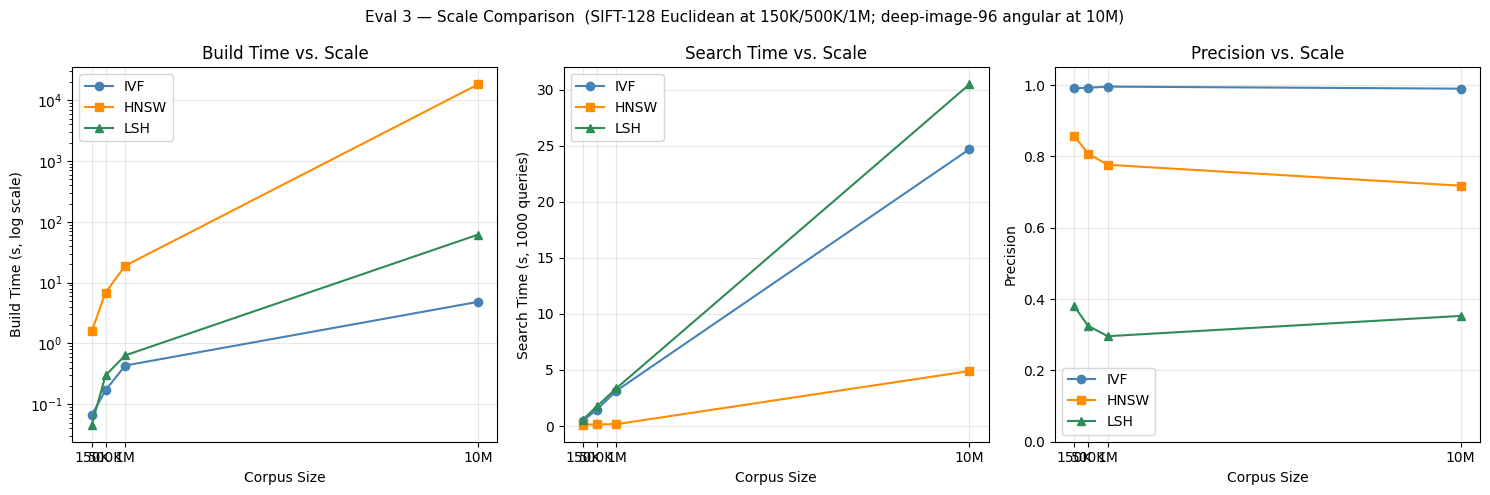

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Eval 3 — Scale Comparison  (SIFT-128 Euclidean at 150K/500K/1M; deep-image-96 angular at 10M)",
    fontsize=11
)

corpus_sizes  = [150_000, 500_000, 1_000_000, 9_990_000]
scale_keys    = list(scale_results.keys())
indexes       = ["clustering", "graph", "lsh"]
display       = {"clustering": "IVF", "graph": "HNSW", "lsh": "LSH"}
colors        = {"clustering": "steelblue", "graph": "darkorange", "lsh": "seagreen"}
markers       = {"clustering": "o", "graph": "s", "lsh": "^"}

for idx_name in indexes:
    kw = dict(marker=markers[idx_name], label=display[idx_name], color=colors[idx_name])
    builds     = [scale_results[l][idx_name]["build"]     for l in scale_keys]
    searches   = [scale_results[l][idx_name]["search"]    for l in scale_keys]
    precisions = [scale_results[l][idx_name]["precision"] for l in scale_keys]
    axes[0].plot(corpus_sizes, builds,     **kw)
    axes[1].plot(corpus_sizes, searches,   **kw)
    axes[2].plot(corpus_sizes, precisions, **kw)

size_ticks  = [150_000, 500_000, 1_000_000, 9_990_000]
size_labels = ["150K", "500K", "1M", "10M"]

for ax in axes:
    ax.set_xticks(size_ticks)
    ax.set_xticklabels(size_labels)
    ax.set_xlabel("Corpus Size")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_yscale("log")
axes[0].set_ylabel("Build Time (s, log scale)")
axes[0].set_title("Build Time vs. Scale")

axes[1].set_ylabel("Search Time (s, 1000 queries)")
axes[1].set_title("Search Time vs. Scale")

axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision vs. Scale")

plt.tight_layout()
plt.savefig("figures/eval3_scale.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# ── Experiment 3: Distribution ────────────────────────────────────────────────
# word2vec (text embeddings, cosine) vs. SIFT (image descriptors, Euclidean)
# Both at 150K vectors. Use first 1000 vectors as queries for word2vec
# (consistent with the rest of the notebook; queries are allowed in the corpus).
N_DIST = 150_000

wv150_data = normalize(data[:N_DIST].astype(np.float32))
wv150_q    = normalize(data[:Q].astype(np.float32))  # first Q vectors as queries
wv150_gt   = compute_gt(wv150_data, wv150_q, "cosine", k)

# sift_150k_data already loaded earlier
sift150_gt = compute_gt(sift_150k_data, sift_q, "euclidean", k)

dist_results = {
    "word2vec (text, 300-dim, cos)": evaluate_dataset(wv150_data,     wv150_q, wv150_gt,   "cosine",    k),
    "sift     (image,128-dim, euc)": evaluate_dataset(sift_150k_data, sift_q,  sift150_gt, "euclidean", k),
}
print_results(dist_results, "Distribution Comparison (150K vectors)")


=== Distribution Comparison (150K vectors) ===
Dataset                    Index         Build(s)  Search(s)  Precision   Recall
--------------------------------------------------------------------------------
word2vec (text, 300-dim, cos) clustering       0.146      1.206     0.8685   0.8685
word2vec (text, 300-dim, cos) graph            2.815      0.131     0.8814   0.8814
word2vec (text, 300-dim, cos) lsh              0.043      0.578     0.5260   0.5260

sift     (image,128-dim, euc) clustering       0.059      0.471     0.9913   0.9913
sift     (image,128-dim, euc) graph            1.350      0.108     0.8564   0.8564
sift     (image,128-dim, euc) lsh              0.025      0.588     0.3796   0.3796



---

### Evaluation 4: Cross-Index Comparison

Using the results from Evaluation 3, compare IVF, HNSW, and LSH head-to-head
across all datasets. For each dataset the table shows precision and search time
for all three indexes, and marks the winner in each category.

In [25]:
def cross_index_comparison(all_results, title):
    """Print a head-to-head comparison table for all indexes across datasets."""
    indexes = ["clustering", "graph", "lsh"]
    labels  = {"clustering": "IVF", "graph": "HNSW", "lsh": "LSH"}

    print(f"\n=== {title} ===")
    # Header
    col = 24
    print(f"{'':<{col}}", end="")
    for idx in indexes:
        print(f"  {labels[idx]:>18}", end="")
    print()
    print(f"{'':<{col}}", end="")
    for _ in indexes:
        print(f"  {'Prec  Search(s)':>18}", end="")
    print()
    print("-" * (col + len(indexes) * 20))

    for dataset, res in all_results.items():
        best_prec  = max(indexes, key=lambda i: res[i]["precision"])
        best_speed = min(indexes, key=lambda i: res[i]["search"])
        print(f"{dataset:<{col}}", end="")
        for idx in indexes:
            r = res[idx]
            prec_str  = f"{r['precision']:.3f}"
            speed_str = f"{r['search']:.3f}s"
            # mark winners with *
            if idx == best_prec:  prec_str  += "*"
            if idx == best_speed: speed_str += "*"
            print(f"  {prec_str:>6} {speed_str:>9}", end="")
        print()
    print("\n* = best in category")


# ── Dimensionality ───────────────────────────────────────────────────────────
cross_index_comparison(dim_results,   "Dimensionality — Mixed (60K vectors)")
cross_index_comparison(glove_results, "Dimensionality — GloVe Sweep (60K vectors, cosine)")

# ── Scale ────────────────────────────────────────────────────────────────────
cross_index_comparison(scale_results, "Scale — SIFT-128 (Euclidean)")

# ── Distribution ─────────────────────────────────────────────────────────────
cross_index_comparison(dist_results,  "Distribution — word2vec vs. SIFT (150K)")


=== Dimensionality — Mixed (60K vectors) ===
                                         IVF                HNSW                 LSH
                             Prec  Search(s)     Prec  Search(s)     Prec  Search(s)
------------------------------------------------------------------------------------
word2vec  (300-dim, cos)   0.886    0.594s  0.909*   0.133s*   0.553    0.302s
glove-25  ( 25-dim, cos)  0.948*    0.118s   0.869   0.073s*   0.582    0.310s
fmnist    (784-dim, euc)  0.999*    1.109s   0.959   0.165s*   0.328    0.319s

* = best in category

=== Dimensionality — GloVe Sweep (60K vectors, cosine) ===
                                         IVF                HNSW                 LSH
                             Prec  Search(s)     Prec  Search(s)     Prec  Search(s)
------------------------------------------------------------------------------------
glove-25  ( 25-dim)       0.948*    0.124s   0.869   0.073s*   0.582    0.311s
glove-50  ( 50-dim)       0.883*    0.116s   0

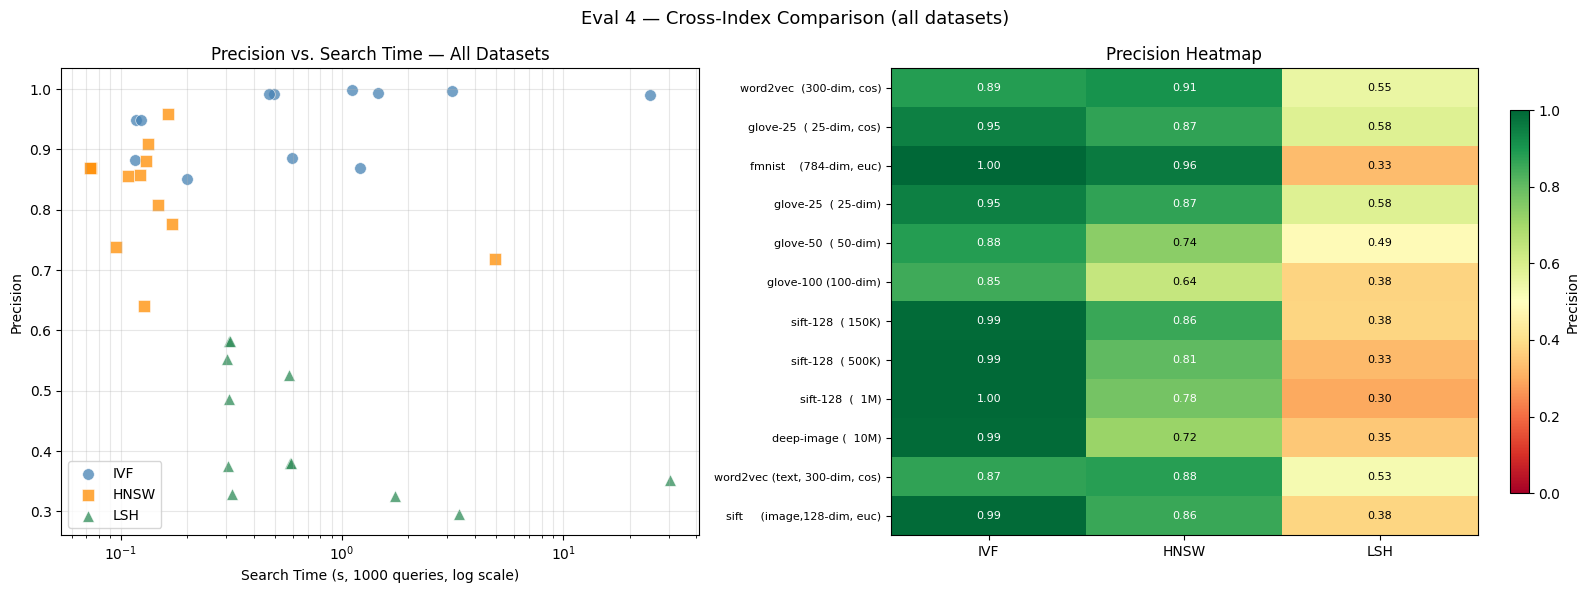

In [30]:
all_eval_results = {**dim_results, **glove_results, **scale_results, **dist_results}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Eval 4 — Cross-Index Comparison (all datasets)", fontsize=13)

indexes       = ["clustering", "graph", "lsh"]
display       = {"clustering": "IVF", "graph": "HNSW", "lsh": "LSH"}
index_colors  = {"clustering": "steelblue", "graph": "darkorange", "lsh": "seagreen"}
index_markers = {"clustering": "o", "graph": "s", "lsh": "^"}

# ── Scatter: Precision vs. Search Time ───────────────────────────────────────
ax = axes[0]
seen = set()
for dataset, res in all_eval_results.items():
    for idx_name, r in res.items():
        label = display[idx_name] if idx_name not in seen else "_nolegend_"
        seen.add(idx_name)
        ax.scatter(r["search"], r["precision"],
                   c=index_colors[idx_name], marker=index_markers[idx_name],
                   s=70, label=label, alpha=0.75, edgecolors="white", linewidths=0.5)
ax.set_xscale("log")
ax.set_xlabel("Search Time (s, 1000 queries, log scale)")
ax.set_ylabel("Precision")
ax.set_title("Precision vs. Search Time — All Datasets")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

# ── Heatmap: Precision per (dataset × index) ─────────────────────────────────
dataset_names = list(all_eval_results.keys())
prec_matrix = np.array([
    [all_eval_results[d][i]["precision"] for i in indexes]
    for d in dataset_names
])

ax = axes[1]
im = ax.imshow(prec_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(indexes)))
ax.set_xticklabels(["IVF", "HNSW", "LSH"], fontsize=10)
ax.set_yticks(range(len(dataset_names)))
ax.set_yticklabels(dataset_names, fontsize=8)
ax.set_title("Precision Heatmap")
for i in range(len(dataset_names)):
    for j in range(len(indexes)):
        val = prec_matrix[i, j]
        text_color = "black" if 0.25 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=text_color)
plt.colorbar(im, ax=ax, fraction=0.03, label="Precision")

plt.tight_layout()
plt.savefig("figures/eval4_comparison.png", dpi=150, bbox_inches="tight")
plt.show()